In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [26]:
df = pd.read_csv('salesweekly.csv')

In [27]:
df

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,1/5/2014,14.00,11.670,21.30,185.950,41.0,0.0,32.000000,7.00
1,1/12/2014,29.33,12.680,37.90,190.700,88.0,5.0,21.000000,7.20
2,1/19/2014,30.67,26.340,45.90,218.400,80.0,8.0,29.000000,12.00
3,1/26/2014,34.00,32.370,31.50,179.600,80.0,8.0,23.000000,10.00
4,2/2/2014,31.02,23.350,20.70,159.880,84.0,12.0,29.000000,12.00
...,...,...,...,...,...,...,...,...,...
297,9/15/2019,35.51,30.977,19.65,178.375,67.2,5.0,30.000000,30.50
298,9/22/2019,46.84,25.396,24.40,248.250,31.2,3.0,26.000000,21.00
299,9/29/2019,34.01,22.498,26.60,336.700,61.2,1.0,40.416667,23.10
300,10/6/2019,38.70,32.502,19.25,249.450,69.0,5.0,30.000000,12.13


In [28]:
date_time = pd.to_datetime(df.pop('datum'), format = '%m/%d/%Y')
df.head()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


In [43]:
sales_rate = np.zeros((len(df), ))
df['sales_rate'] = sales_rate


high_sales = 1.0
low_sales = 0.0

column_list = list(df)
for index, row in df.iterrows():
    total_sales = row.sum()
    #print(row)
    if total_sales > 400:
        df.at[index, 'sales_rate'] = high_sales

#drop the sales_rate column and make it the target data
targets = df.pop('sales_rate')
print(targets.head())
print('==================')
print(df.head())
column_list = list(df)

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: sales_rate, dtype: float64
      M01AB     M01AE     N02BA     N02BE      N05B      N05C       R03  \
0 -0.489780 -0.440055  0.142468  0.059622  0.184881 -0.264531  0.056241   
1  0.133976 -0.411376 -0.268095  0.047134 -0.234070 -0.055033  0.152307   
2  0.102875  0.023500 -0.465957 -0.025695 -0.162759 -0.246771  0.082441   
3  0.025587 -0.147722 -0.109806  0.076318 -0.162759 -0.246771  0.134840   
4  0.094752  0.108401  0.157307  0.128165 -0.198415 -0.502423  0.082441   

        R06  
0 -0.232388  
1 -0.228873  
2  0.144526  
3  0.179670  
4  0.144526  


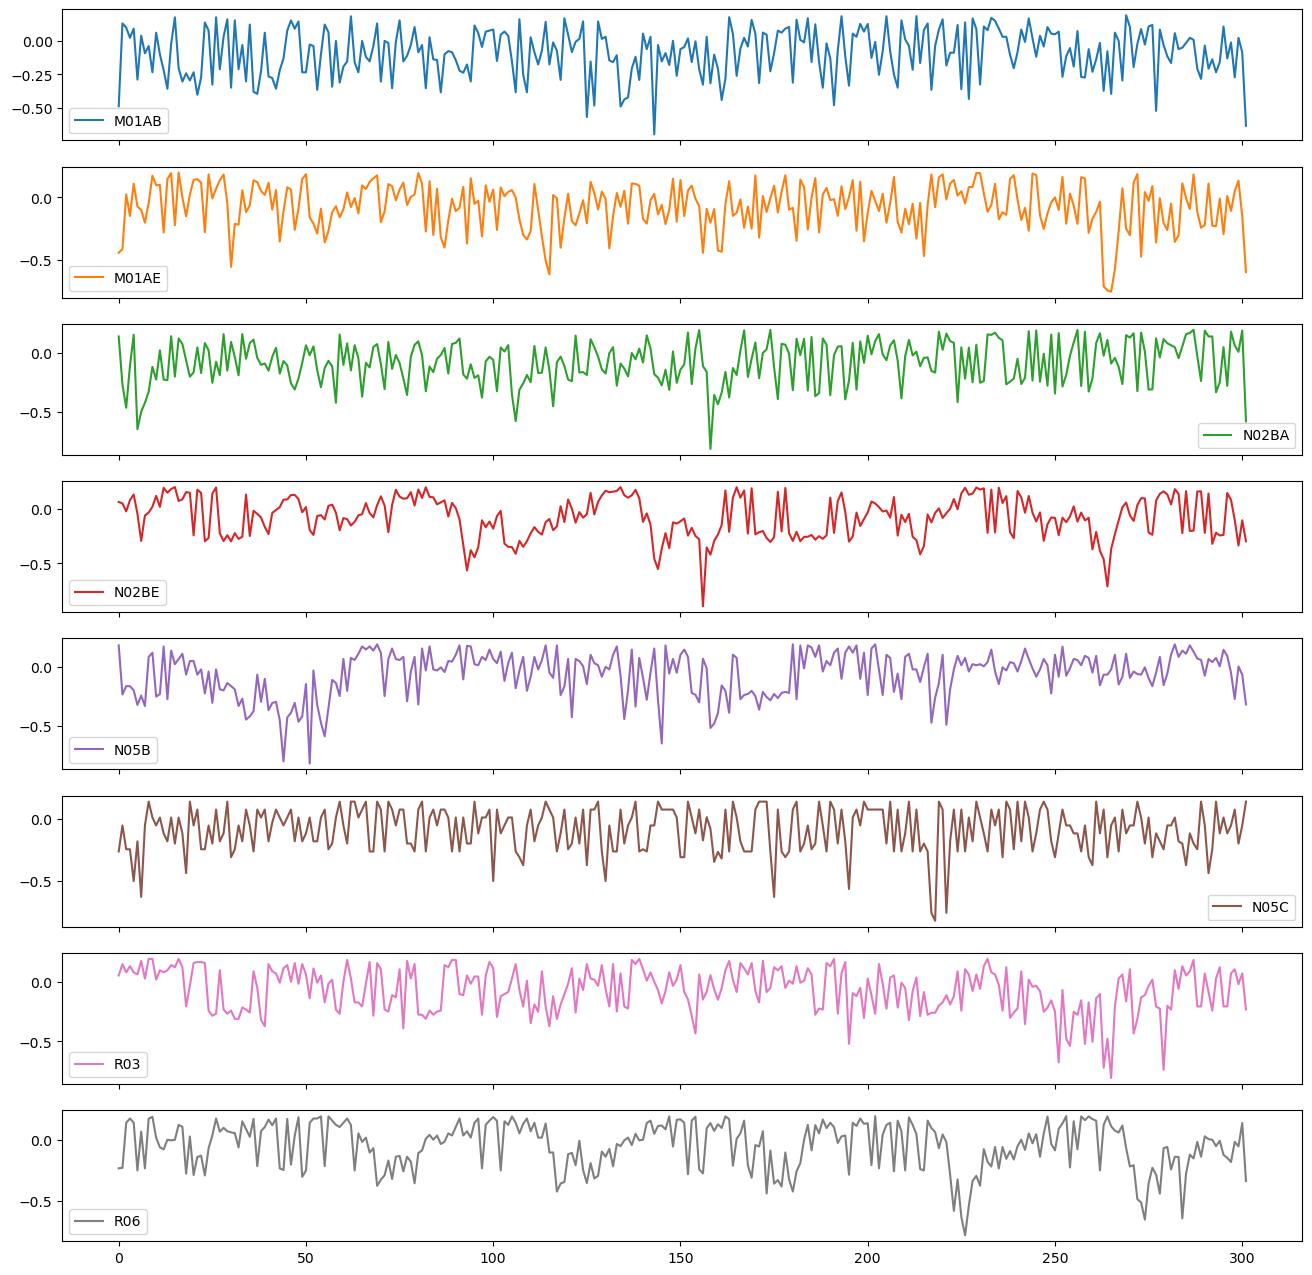

In [44]:
mpl.rcParams['figure.figsize'] = (16, 16)
plot_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
plot_features = df[plot_cols]
_ = plot_features.plot(subplots=True)
plt.show()

In [39]:
#build custom functions to help model building 

def z_score (df, column_list):
  # Standardize features
  for field in column_list:
    # get the mean and standard deviations
    mean, std = df[field].mean(), df[field].std()
    
    # get the ...
    df.loc[:,field] = (df[field] - mean) / std
    
  ##data = ( data - data.mean() ) / data.std()
  
  return df
# for remove negative values from dataset
def remove_negation(df):
  for index, row in df.iterrows():
    if row['M01AB'] * -1 < 1:
      df.at[index, 'M01AB'] = -row['M01AB']
    if row['M01AE'] * -1 < 1:
      df.at[index, 'M01AE'] = -row['M01AE']
    if row['N02BA'] * -1 < 1:
      df.at[index, 'N02BA'] = -row['N02BA']
    if row['N02BE'] * -1 < 1:
      df.at[index, 'N02BE'] = -row['N02BE']
    if row['N05B'] * -1 < 1:
      df.at[index, 'N05B'] = -row['N05B']
    if row['N05C'] * -1 < 1:
      df.at[index, 'N05C'] = -row['N05C']
    if row['R03'] * -1 < 1:
      df.at[index, 'R03'] = -row['R03']
    if row['R06'] * -1 < 1:
      df.at[index, 'R06'] = -row['R06']
  return df 
    
def divide_through_by_5(df):
    df = df / 5
    return df    

#for squashing the values to lie between 0 and 1
def normalize(df, column_list):
    print("normalizing dataset...")
    df = z_score(df, column_list)
    df = remove_negation(df)
    df = divide_through_by_5(df)

    return df

In [40]:
#Normalize the data
df = normalize(df, column_list)
print(df.head())

normalizing dataset...
      M01AB     M01AE     N02BA     N02BE      N05B      N05C       R03  \
0 -0.489780 -0.440055  0.142468  0.059622  0.184881 -0.264531  0.056241   
1  0.133976 -0.411376 -0.268095  0.047134 -0.234070 -0.055033  0.152307   
2  0.102875  0.023500 -0.465957 -0.025695 -0.162759 -0.246771  0.082441   
3  0.025587 -0.147722 -0.109806  0.076318 -0.162759 -0.246771  0.134840   
4  0.094752  0.108401  0.157307  0.128165 -0.198415 -0.502423  0.082441   

        R06  
0 -0.232388  
1 -0.228873  
2  0.144526  
3  0.179670  
4  0.144526  


In [45]:
#column_indices = {name: i for i, name in enumerate(data.columns)}
n = len(df)
features = df.values
targets = targets.values
# Split for the features training, features validation, and features test sets in ratio of 70% , 20% and 10%
features_train = features[0:int(n*0.7)]             
features_val = features[int(n*0.7):int(n*0.9)]
features_test = features[int(n*0.9):]

# Also split the target training, target validation and target test sets in ration of 70%, 20% and 10%
targets_train = targets[0:int(n*0.7)]
targets_val = targets[int(n*0.7):int(n*0.9)]
targets_test = targets[int(n*0.9):]

In [47]:
np.random.seed(42)

# define the activation function
def sigmoid(x):
    """
    Calculate sigmoid
    """
    return 1 / (1 + np.exp(-x))


# Hyperparameters
n_hidden = 3  # number of hidden units
epochs = 3000
learnrate = 0.00008
bias = 0.001

n_records, n_features = features.shape
last_loss = None

# Initialize weights
weights_input_hidden = np.random.normal(scale=1 / n_features ** .5,
                                        size=(n_features, n_hidden))
weights_hidden_1_hidden_2 = np.random.normal(scale=1 / n_features ** .5,
                                        size=(n_hidden, n_hidden))
weights_hidden_output = np.random.normal(scale=1 / n_features ** .5,
                                         size=n_hidden)

for e in range(epochs):
    del_w_input_hidden = np.zeros(weights_input_hidden.shape)
    del_w_hidden_output = np.zeros(weights_hidden_output.shape)
    del_w_hidden_1_2 = np.zeros(weights_hidden_1_hidden_2.shape)
    for x, y in zip(features_train, targets_train):
        ## Forward pass ##
        # Calculate the output
        hidden_1 = np.dot(x, weights_input_hidden) + bias
        hidden_1_output = sigmoid(hidden_1)
        hidden_2 = np.dot(hidden_1_output, weights_hidden_1_hidden_2) + bias
        hidden_2_output = sigmoid(hidden_2)

        output = sigmoid(np.dot(hidden_2_output,
                                weights_hidden_output))

        ## Backward pass ##
        # Calculate the network's prediction error
        error = y - output

        # Calculate error term for the output unit
        output_error_term = error * output * (1 - output)

        ## propagate errors back to the hidden one layer

        # Calculate the hidden layer's contribution to the error
        hidden_2_error = np.dot(output_error_term, weights_hidden_output)

        # Calculate the error term for the second hidden layer
        hidden_2_error_term = hidden_2_error * hidden_2_output * (1 - hidden_2_output)

        # Caculate the error for the first hidden layer
        hidden_1_error = np.dot(hidden_2_error_term, weights_hidden_1_hidden_2)

        # Calculate the error term for the first hidden layer
        hidden_1_error_term = hidden_1_error * hidden_1_output * (1 - hidden_1_output)

        # Update the change in weights
        del_w_hidden_output += output_error_term * hidden_2_output
        del_w_hidden_1_2 += hidden_2_error_term * hidden_1_output
        del_w_input_hidden += hidden_1_error_term * x[:, None]

    # Update weights
    weights_input_hidden += learnrate * del_w_input_hidden / n_records
    weights_hidden_1_hidden_2 += learnrate + del_w_hidden_1_2 / n_records
    weights_hidden_output += learnrate * del_w_hidden_output / n_records
    
    # Printing out the mean square error on the training set
    if e % (epochs / 10) == 0:
        print("Epoch: {0} / {1}".format(e, epochs))
        hidden_1_output = sigmoid(np.dot(x, weights_input_hidden) + bias)
        hidden_2_output = sigmoid(np.dot(hidden_1_output, weights_hidden_1_hidden_2) + bias)
        out = sigmoid(np.dot(hidden_2_output,
                             weights_hidden_output) + bias)
        loss = np.mean((out - targets) ** 2)

        if last_loss and last_loss < loss:
            print("Train loss: ", loss, "  WARNING - Loss Increasing")
        else:
            print("Train loss: ", loss)
        last_loss = loss
        print("=======================================")
 
    ## if validation data set is extracted along with the training and test sets
    if  e % (epochs / 10) == 0:
        hidden_1_output = sigmoid(np.dot(features_val, weights_input_hidden) + bias)
        hidden_2_output = sigmoid(np.dot(hidden_1_output, weights_hidden_1_hidden_2) + bias)
        out = sigmoid(np.dot(hidden_2_output,
                             weights_hidden_output) + bias)
        loss = np.mean((out - targets_val))
        
        if last_loss and last_loss < loss:
            print("Validation Loss: ", loss, " WARNING - Loss Increasing")

# Calculate accuracy on test data
hidden_1 = sigmoid(np.dot(features_test, weights_input_hidden) + bias)
hidden_2 = sigmoid(np.dot(hidden_1, weights_hidden_1_hidden_2) + bias)
out = sigmoid(np.dot(hidden_2, weights_hidden_output) + bias)
predictions = out > 0.5
accuracy = np.mean(predictions == targets_test)
print("Prediction accuracy: {:.3f}".format(accuracy))

Epoch: 0 / 3000
Train loss:  0.20277749442849738
Validation Loss:  0.44974918044218687  WARNING - Loss Increasing
Epoch: 300 / 3000
Train loss:  0.13631080735355014
Validation Loss:  0.36864598312864844  WARNING - Loss Increasing
Epoch: 600 / 3000
Train loss:  0.11663134380663051
Validation Loss:  0.34115275767867426  WARNING - Loss Increasing
Epoch: 900 / 3000
Train loss:  0.10885076378768653
Validation Loss:  0.32968336146739846  WARNING - Loss Increasing
Epoch: 1200 / 3000
Train loss:  0.10476485015594206
Validation Loss:  0.3235008938527208  WARNING - Loss Increasing
Epoch: 1500 / 3000
Train loss:  0.10221956557958958
Validation Loss:  0.31958785426164504  WARNING - Loss Increasing
Epoch: 1800 / 3000
Train loss:  0.10044833187707149
Validation Loss:  0.31683437683712073  WARNING - Loss Increasing
Epoch: 2100 / 3000
Train loss:  0.09911712983876855
Validation Loss:  0.31474731375065  WARNING - Loss Increasing
Epoch: 2400 / 3000
Train loss:  0.098058855864987
Validation Loss:  0.3130